# Notebook 01 — Data Description

This notebook documents the raw data behind the study: asset coverage, price and return
behaviour, and the distributional features — fat tails, skewness, volatility clustering —
that motivate the regime analysis. Every table and figure is computed **separately by
panel** and written to `outputs/01_descriptive_data/`, from where the report picks them up.

**Two ETF panels** (defined in `src/settings/tickers.py`):

- **Panel A — cross-asset (n = 9):** SPY, SHY, TLT, AGG, HYG, GLD, DBC, USO, VNQ. Spans equity, government and credit fixed income, gold, broad commodities, oil, and real estate; this is the core diversification panel.
- **Panel B — international equity (n = 6):** SPY, EFA, EEM, EWG, EWU, EWJ. An equity-only panel across regions, used to test whether global equity markets collapse onto a single common factor under stress.

SPY is the only ticker common to both panels, so it is reported once per panel — pooling the panels would mix two different research questions and bias the cross-asset panel toward equity.

In [1]:
# =====================================================================
# Notebook 01 -- Data Description: setup
#
# Reads adjusted daily ETF prices from the project database and writes every
# report table (CSV) and figure (PNG) to outputs/01_descriptive_data/, so the
# data section of the report is fully reproducible from this notebook.
# =====================================================================
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import duckdb
from scipy import stats
from plotnine import *

# Bootstrap the src/ path from the notebook location, then switch to the
# repository-anchored paths so output locations are independent of the cwd.
sys.path.insert(0, str(Path.cwd().parents[0] / "src"))
from settings.paths import DB_PATH, PROJECT_ROOT
from settings.tickers import PANEL_A, PANEL_B

OUTPUT_DIR = PROJECT_ROOT / "outputs" / "01_descriptive_data"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

con = duckdb.connect(str(DB_PATH), read_only=True)

# Shared plotnine theme, and one saver so every figure is written at the
# resolution the report expects (dpi = 180).
theme_seminar = theme_bw() + theme(
    figure_size=(9, 5),
    plot_title=element_text(weight="bold"),
    strip_background=element_rect(fill="#e8e8e8"),
)

def save_fig(plot, name, width=9, height=5):
    """Write a plotnine figure to OUTPUT_DIR/name at report resolution."""
    plot.save(OUTPUT_DIR / name, width=width, height=height, units="in", dpi=180, verbose=False)

# Panel membership: SPY is the only ticker common to both panels, so it is
# tagged once per panel and every figure can facet cleanly by panel.
PANEL_MEMBERSHIP = pd.concat([
    pd.DataFrame({"ticker": PANEL_A, "panel": "Panel A: Cross-asset"}),
    pd.DataFrame({"ticker": PANEL_B, "panel": "Panel B: International equity"}),
], ignore_index=True)
PANEL_ORDER = ["Panel A: Cross-asset", "Panel B: International equity"]

print(f"Database: {DB_PATH}")
print(f"Outputs : {OUTPUT_DIR}")

Database: C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\data\lsr.duckdb
Outputs : C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\01_descriptive_data


In [2]:
raw = con.execute("SELECT * FROM asset_prices").fetchdf()
raw["date"] = pd.to_datetime(raw["date"])

universe = set(PANEL_A) | set(PANEL_B)
missing = universe - set(raw["ticker"].unique())
assert not missing, f"Missing price history for tickers: {sorted(missing)}"

# Long-format, panel-tagged table. Tickers in both panels (SPY) get one row
# per panel so every downstream figure can facet/group cleanly by panel.
df = raw.merge(PANEL_MEMBERSHIP, on="ticker", how="inner")
df["panel"] = pd.Categorical(df["panel"], categories=PANEL_ORDER, ordered=True)
df = df.sort_values(["panel", "ticker", "date"]).reset_index(drop=True)

print(f"{raw['ticker'].nunique()} tickers in the database; "
      f"{len(universe)} in the fixed universe; {df.shape[0]:,} panel-tagged rows.")

14 tickers in the database; 14 in the fixed universe; 87,258 panel-tagged rows.


## 1. Data coverage

Which assets do we have, and over what window? Panels A and B contain different
instruments with different inception dates, so coverage determines the **common,
fully-overlapping window** available for each panel's later correlation and concentration
analysis. Coverage is examined separately by panel and exported as `asset_availability.csv`
(the source for the report's data-availability table).

In [3]:
# --- Date coverage per ticker, within panel ---
coverage = (
    df.groupby(["panel", "ticker"], observed=True)["date"]
    .agg(start="min", end="max", n_obs="count")
)
coverage["years"] = (coverage["end"] - coverage["start"]).dt.days / 365.25
coverage = coverage.sort_values(["panel", "start"])

# Reproducible output: asset-level availability table (feeds the report).
coverage.reset_index().to_csv(OUTPUT_DIR / "asset_availability.csv", index=False)
print(coverage.round(2))

# --- Common (fully-overlapping) sample window per panel ---
# The latest inception date within a panel bounds the balanced window over
# which every member of that panel is simultaneously observed.
common_start = (
    df.groupby(["panel", "ticker"], observed=True)["date"].min()
    .groupby("panel", observed=True).max()
    .rename("common_start")
)
common_end = df.groupby("panel", observed=True)["date"].max().rename("common_end")
print("\nCommon sample window per panel:")
print(pd.concat([common_start, common_end], axis=1))

                                          start        end  n_obs  years
panel                         ticker                                    
Panel A: Cross-asset          SPY    2000-01-03 2025-12-30   6538  25.99
                              SHY    2002-07-30 2025-12-30   5894  23.42
                              TLT    2002-07-30 2025-12-30   5894  23.42
                              AGG    2003-09-29 2025-12-30   5600  22.25
                              VNQ    2004-09-29 2025-12-30   5348  21.25
                              GLD    2004-11-18 2025-12-30   5312  21.11
                              DBC    2006-02-06 2025-12-30   5007  19.90
                              USO    2006-04-10 2025-12-30   4963  19.72
                              HYG    2007-04-11 2025-12-30   4712  18.72
Panel B: International equity EWG    2000-01-03 2025-12-30   6538  25.99
                              EWJ    2000-01-03 2025-12-30   6538  25.99
                              EWU    2000-01-03 202

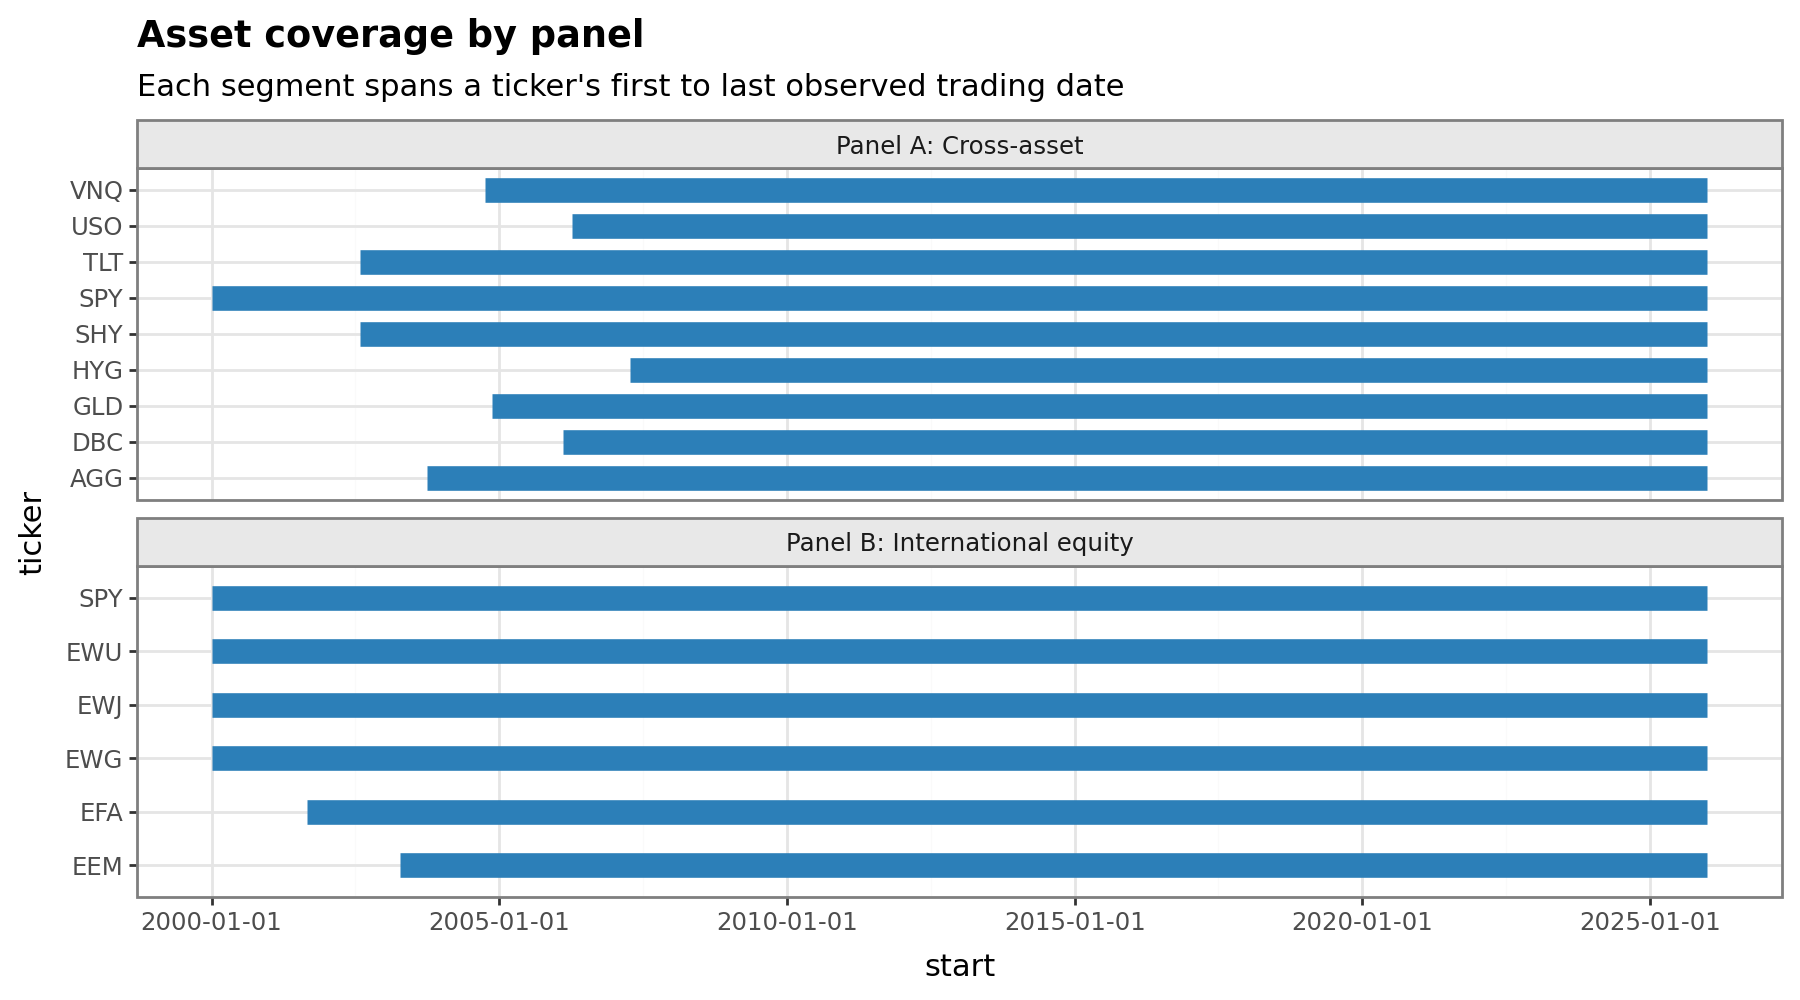

In [4]:
# --- Coverage timeline (Gantt), faceted by panel ---
cov_plot = coverage.reset_index().sort_values(["panel", "start"])
p_coverage = (
    ggplot(cov_plot, aes(x="start", xend="end", y="ticker", yend="ticker"))
    + geom_segment(size=5, color="#2c7fb8")
    + facet_wrap("~panel", scales="free_y", ncol=1)
    + labs(
        title="Asset coverage by panel",
        subtitle="Each segment spans a ticker's first to last observed trading date",
        x=None, y=None,
    )
    + theme_seminar
)
save_fig(p_coverage, "asset_coverage_timeline.png", width=9, height=6)
p_coverage

In [5]:
# --- Quality check: any missing prices after a ticker first appears? ---
missing_after_first = []
for (panel, ticker), g in df.groupby(["panel", "ticker"], observed=True):
    first_date = g["date"].min()
    have = set(g.loc[g["price"].notna(), "date"])
    expected = df.loc[(df["panel"] == panel) & (df["date"] >= first_date), "date"].unique()
    gaps = sorted(d for d in expected if d not in have)
    if gaps:
        missing_after_first.append(
            {"panel": panel, "ticker": ticker, "n_missing": len(gaps),
             "first_missing": gaps[0], "last_missing": gaps[-1]}
        )

print("No intra-history price gaps." if not missing_after_first
      else pd.DataFrame(missing_after_first).to_string(index=False))

No intra-history price gaps.


## 2. Price levels

Raw price levels are not comparable across assets — they reflect each fund's share structure, not its risk or return profile. We summarise level distributions, then rebase each panel to 100 at its **common sample start** from Section 1 (not each ticker's own inception), so growth trajectories are visually comparable from the same reference date rather than from arbitrary, staggered starting points.

In [6]:
# --- Price descriptive stats, by panel ---
df.groupby(["panel", "ticker"], observed=True)["price"].describe().round(2)

count    mean     std    min     25%  \
panel                         ticker                                          
Panel A: Cross-asset          AGG     5600.0   76.45   15.27  48.77   62.24   
                              DBC     5007.0   18.94    4.91   9.14   14.28   
                              GLD     5312.0  136.16   59.61  41.26  106.17   
                              HYG     4712.0   51.27   13.45  21.78   40.21   
                              SHY     5894.0   66.88    7.57  51.33   62.66   
                              SPY     6538.0  195.40  152.11  49.68   84.25   
                              TLT     5894.0   78.19   26.02  35.98   54.09   
                              USO     4963.0  205.16  171.57  17.04   75.55   
                              VNQ     5348.0   50.66   21.99  10.45   30.80   
Panel B: International equity EEM     5716.0   30.86    9.56   7.20   26.65   
                              EFA     6122.0   44.28   16.76  15.02   32.47   
                              EWG     6538.0   19.02    7.68   4.90   12.93   
                              EWJ     6538.0   40.10   13.08  17.55   29.52   
                              EWU     6538.0   21.09    6.60   8.67   16.00   
                              SPY     6538.0  195.40  152.11  49.68   84.25   

                                         50%     75%     max  
panel                         ticker                          
Panel A: Cross-asset          AGG      79.80   88.09  100.65  
                              DBC      20.07   21.92   38.65  
                              GLD     124.95  166.38  416.74  
                              HYG      51.03   61.91   78.76  
                              SHY      68.47   72.35   81.65  
                              SPY     115.54  259.29  686.73  
                              TLT      82.33   94.89  143.26  
                              USO     113.04  295.24  939.84  
                              VNQ      50.52   69.12   97.23  
Panel B: International equity EEM      31.67   36.59   54.93  
                              EFA      43.11   53.67   95.07  
                              EWG      19.39   23.92   42.41  
                              EWJ      38.07   48.73   81.37  
                              EWU      21.25   24.98   43.62  
                              SPY     115.54  259.29  686.73

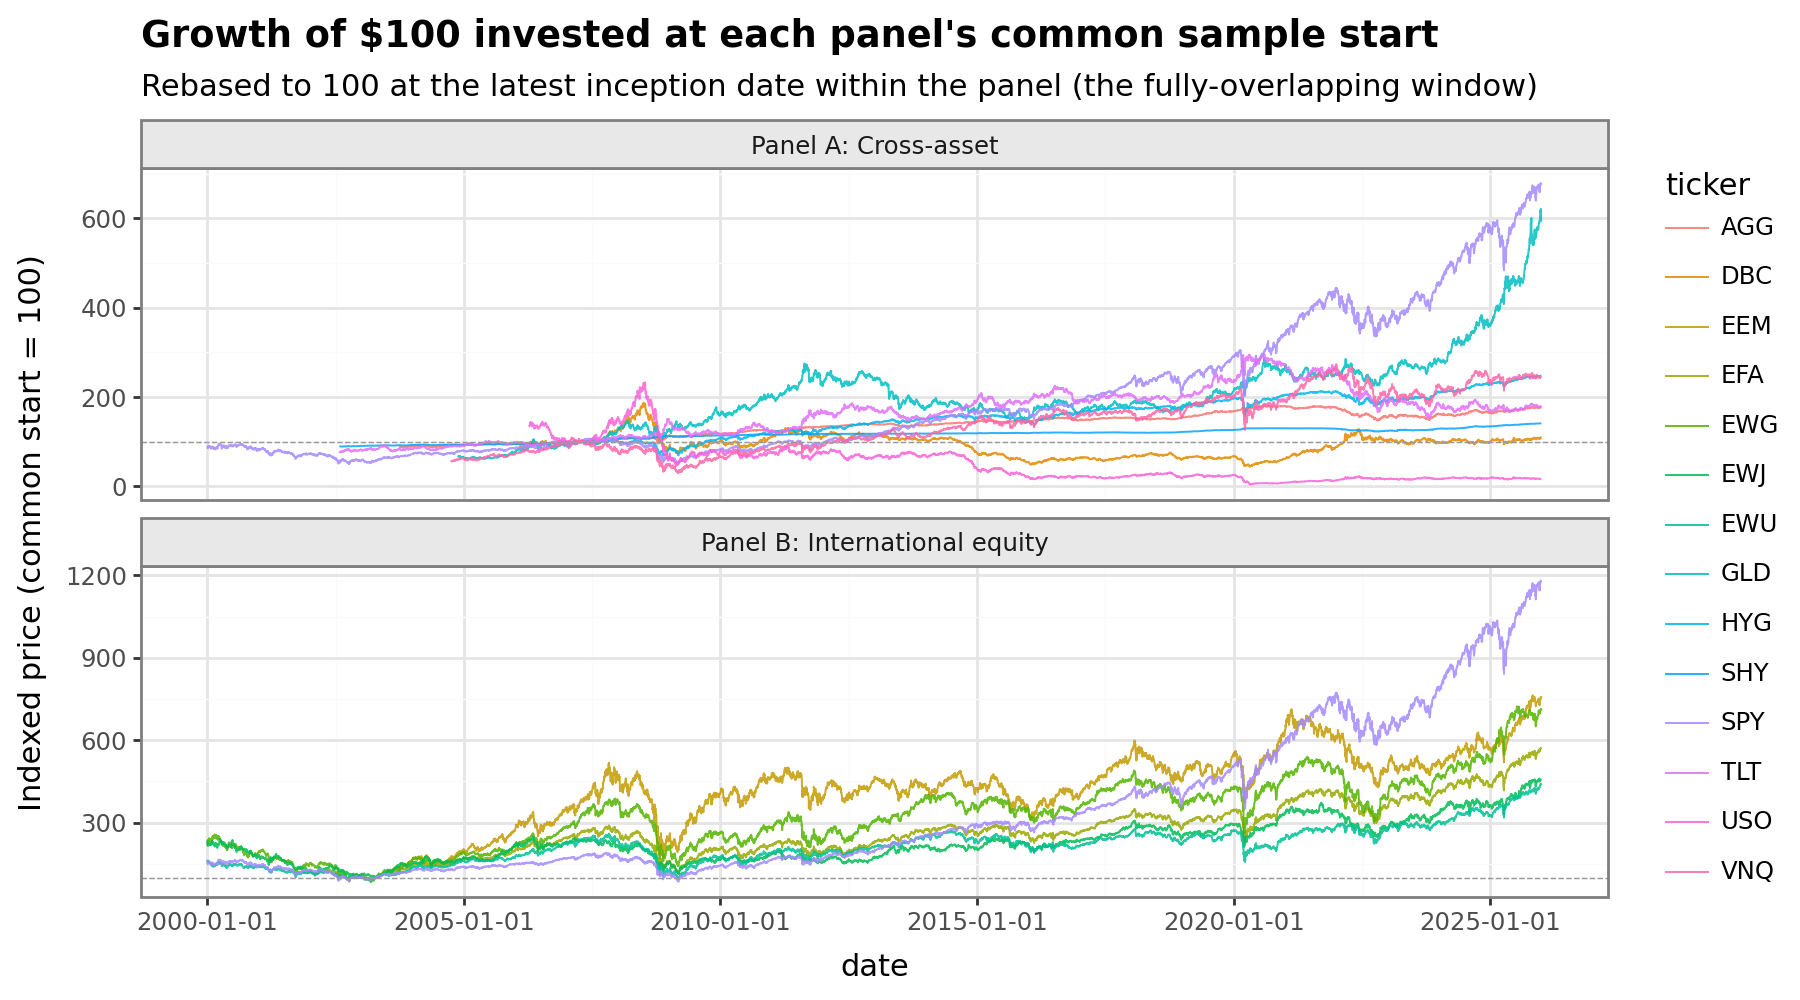

In [7]:
# --- Normalized price history, rebased to 100 at the panel's common start ---
common_start_map = common_start.to_dict()

def base_price_for(group):
    cs = common_start_map[group.name[0]]
    return group.loc[group["date"] >= cs, "price"].iloc[0]

base_price = (
    df.sort_values("date")
    .groupby(["panel", "ticker"], observed=True)
    .apply(base_price_for, include_groups=False)
    .rename("base_price")
)

df = df.merge(base_price.reset_index(), on=["panel", "ticker"], how="left")
df["price_norm"] = df["price"] / df["base_price"] * 100

p_norm = (
    ggplot(df, aes(x="date", y="price_norm", color="ticker"))
    + geom_line(size=0.4, alpha=0.85)
    + geom_hline(yintercept=100, linetype="dashed", color="#999999", size=0.3)
    + facet_wrap("~panel", ncol=1, scales="free_y")
    + labs(
        title="Growth of $100 invested at each panel's common sample start",
        subtitle="Rebased to 100 at the latest inception date within the panel (the fully-overlapping window)",
        x=None, y="Indexed price (common start = 100)",
    )
    + theme_seminar
)
save_fig(p_norm, "normalized_price_history.png", width=9, height=7)
p_norm

## 3. Returns

Daily returns reveal the risk profile that price levels obscure: fat tails, skewness, and volatility clustering are key stylised facts of financial return data. Throughout the paper we use daily **log returns**,
$$ r_{i,t} = \ln(P_{i,t}) - \ln(P_{i,t-1}), $$
since they are additive across time and numerically close to simple returns at daily frequency. We use the same definition here for consistency with the data section of the report.

In [8]:
# --- Daily log returns and per-ticker descriptive moments, by panel ---
df = df.sort_values(["panel", "ticker", "date"])
df["log_return"] = df.groupby(["panel", "ticker"], observed=True)["price"].transform(
    lambda x: np.log(x).diff()
)
ret = df.dropna(subset=["log_return"])

ret_stats = ret.groupby(["panel", "ticker"], observed=True)["log_return"].agg(n="count", mean="mean", std="std")
ret_stats["mean_ann_pct"] = (ret_stats["mean"] * 252 * 100).round(2)
ret_stats["std_ann_pct"] = (ret_stats["std"] * np.sqrt(252) * 100).round(2)
ret_stats["skew"] = ret.groupby(["panel", "ticker"], observed=True)["log_return"].skew().round(4)
ret_stats["kurt_excess"] = ret.groupby(["panel", "ticker"], observed=True)["log_return"].apply(pd.Series.kurt).round(4)

descriptive = ret_stats[["n", "mean_ann_pct", "std_ann_pct", "skew", "kurt_excess"]].rename(
    columns={"n": "N", "skew": "skewness", "kurt_excess": "excess_kurtosis"}
).sort_index()

# Reproducible output: one descriptive-statistics table per panel (feeds the report).
descriptive.loc["Panel A: Cross-asset"].to_csv(OUTPUT_DIR / "descriptive_stats_panel_a.csv")
descriptive.loc["Panel B: International equity"].to_csv(OUTPUT_DIR / "descriptive_stats_panel_b.csv")

descriptive

N  mean_ann_pct  std_ann_pct  \
panel                         ticker                                    
Panel A: Cross-asset          AGG     5599          3.10         5.21   
                              DBC     5006          0.83        19.22   
                              GLD     5311         10.42        17.67   
                              HYG     4711          4.87        10.99   
                              SHY     5893          1.98         1.52   
                              SPY     6537          7.77        19.40   
                              TLT     5893          3.74        14.38   
                              USO     4962        -10.43        36.76   
                              VNQ     5347          7.08        28.70   
Panel B: International equity EEM     5715          8.93        27.01   
                              EFA     6121          6.05        20.86   
                              EWG     6537          4.35        25.48   
                              EWJ     6537          2.52        21.38   
                              EWU     6537          3.79        22.47   
                              SPY     6537          7.77        19.40   

                                      skewness  excess_kurtosis  
panel                         ticker                             
Panel A: Cross-asset          AGG      -2.0511          54.5714  
                              DBC      -0.4875           3.3461  
                              GLD      -0.3363           5.8703  
                              HYG       0.3117          38.9339  
                              SHY       0.2846           7.1044  
                              SPY      -0.2093          11.5358  
                              TLT      -0.0192           3.4008  
                              USO      -1.1023          13.9327  
                              VNQ      -0.5365          18.7304  
Panel B: International equity EEM       0.0207          16.1523  
                              EFA      -0.3205          12.6584  
                              EWG      -0.2198           9.0099  
                              EWJ      -0.0561           7.3201  
                              EWU      -0.5055          12.6966  
                              SPY      -0.2093          11.5358

In [9]:
# --- Appendix LaTeX tables: coverage + descriptive stats (input by the report appendix) ---
# Writes the tabular bodies that report/sections/appendix.tex \input's directly
# (tab:availability, tab:desc_panel_a, tab:desc_panel_b), so those appendix tables
# always reflect the database and can never drift from the pipeline again.
PANEL_TEX = {"Panel A: Cross-asset": "Cross-asset",
             "Panel B: International equity": "International equity"}

def _write_availability_tabular(path):
    lines = ["\\begin{tabular}{llcc}", "\\toprule",
             "Panel & Ticker & First observation & Number of daily observations \\\\",
             "\\midrule"]
    for panel_index, panel in enumerate(PANEL_ORDER):
        if panel_index:
            lines.append("\\midrule")
        for ticker, row in coverage.loc[panel].iterrows():
            lines.append(f"{PANEL_TEX[panel]} & {ticker} & {row['start']:%Y-%m-%d} & {row['n_obs']:,} \\\\")
    lines += ["\\bottomrule", "\\end{tabular}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

def _write_descriptive_tabular(panel, path):
    lines = ["\\begin{tabular}{lrrrrr}", "\\toprule",
             "Ticker & $N$ & Mean (ann., \\%) & Std.\\ dev.\\ (ann., \\%) & Skewness & Excess kurtosis \\\\",
             "\\midrule"]
    for ticker, row in descriptive.loc[panel].sort_index().iterrows():
        lines.append(
            f"{ticker} & {row['N']:,.0f} & ${row['mean_ann_pct']:.2f}$ & ${row['std_ann_pct']:.2f}$ & "
            f"${row['skewness']:.2f}$ & ${row['excess_kurtosis']:.2f}$ \\\\"
        )
    lines += ["\\bottomrule", "\\end{tabular}"]
    path.write_text("\n".join(lines) + "\n", encoding="utf-8")

_write_availability_tabular(OUTPUT_DIR / "appendix_availability_tabular.tex")
_write_descriptive_tabular("Panel A: Cross-asset", OUTPUT_DIR / "appendix_desc_panel_a_tabular.tex")
_write_descriptive_tabular("Panel B: International equity", OUTPUT_DIR / "appendix_desc_panel_b_tabular.tex")

for name in ("appendix_availability_tabular.tex",
             "appendix_desc_panel_a_tabular.tex",
             "appendix_desc_panel_b_tabular.tex"):
    print(f"[ok] wrote {name}")


[ok] wrote appendix_availability_tabular.tex
[ok] wrote appendix_desc_panel_a_tabular.tex
[ok] wrote appendix_desc_panel_b_tabular.tex


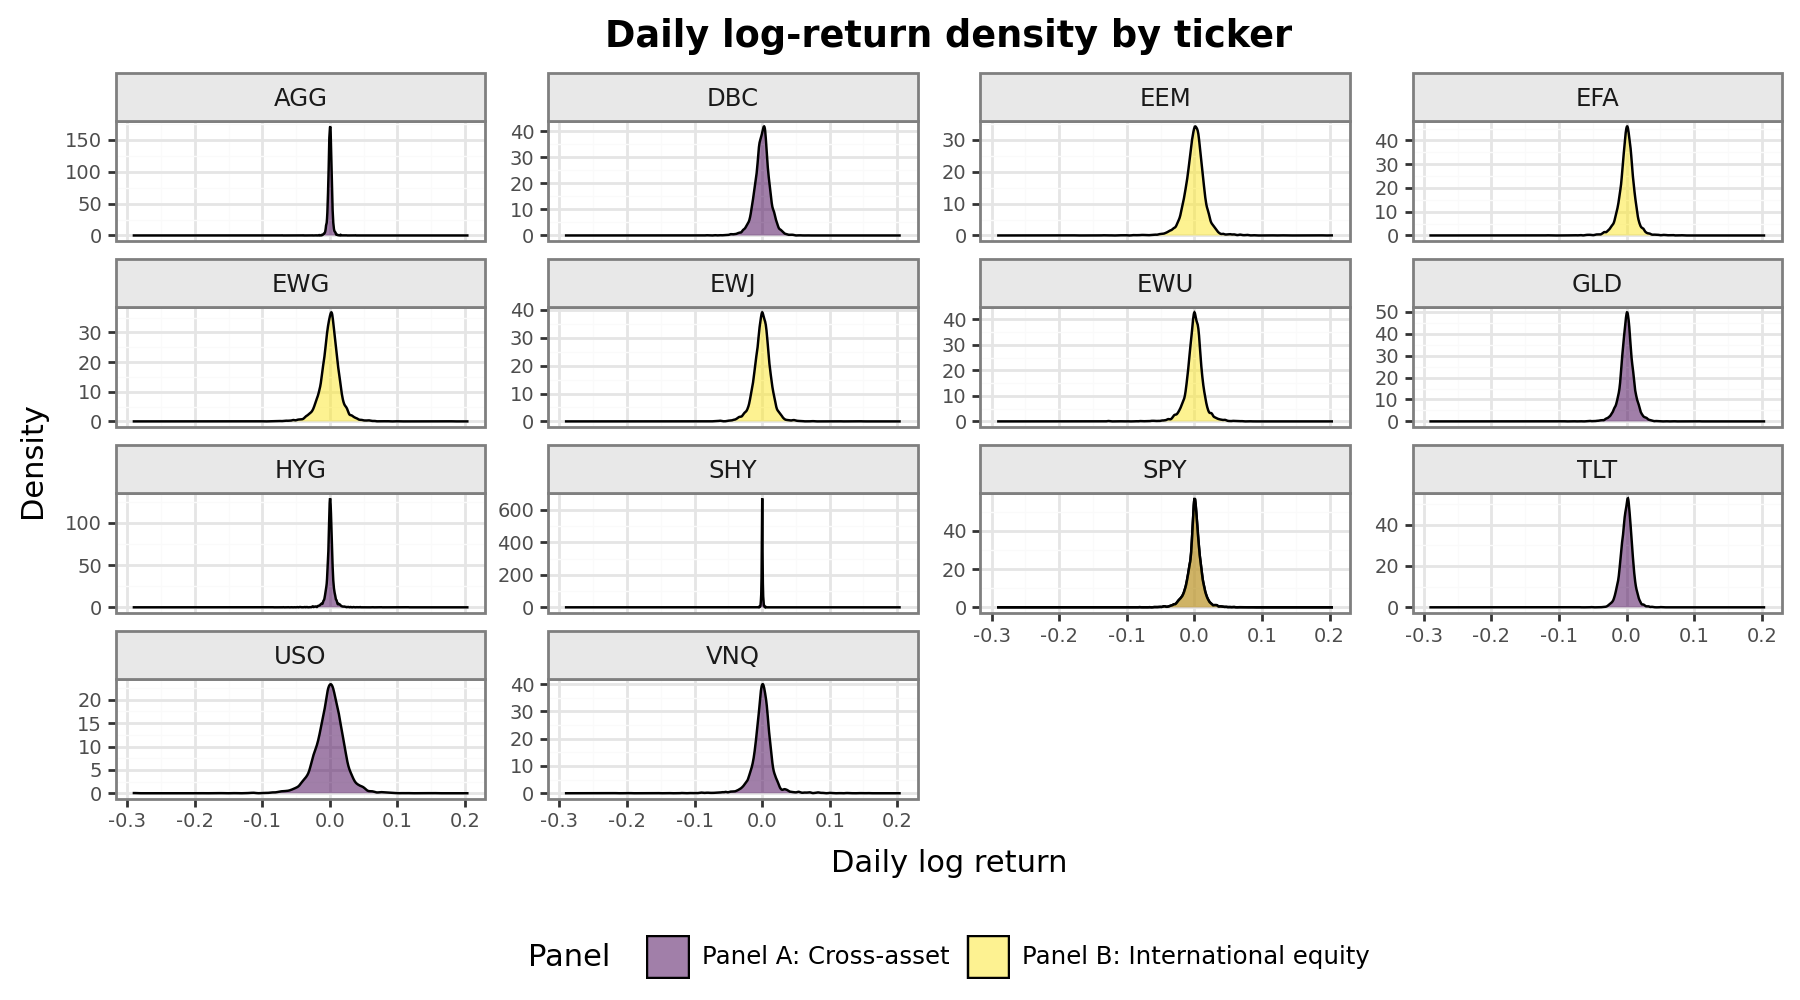

In [10]:
# --- Return density per ticker (faceted), colored by panel ---
p_density = (
    ggplot(ret, aes(x="log_return", fill="panel"))
    + geom_density(alpha=0.5)
    + facet_wrap("~ticker", scales="free_y")
    + labs(title="Daily log-return density by ticker", x="Daily log return", y="Density", fill="Panel")
    + theme_seminar
    + theme(axis_text=element_text(size=7), legend_position="bottom")
)
save_fig(p_density, "return_density_by_ticker.png", width=11, height=8)
p_density

C:\Users\salio\PythonEnvironments\main_venv_py312\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


C:\Users\salio\PythonEnvironments\main_venv_py312\Lib\site-packages\plotnine\layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


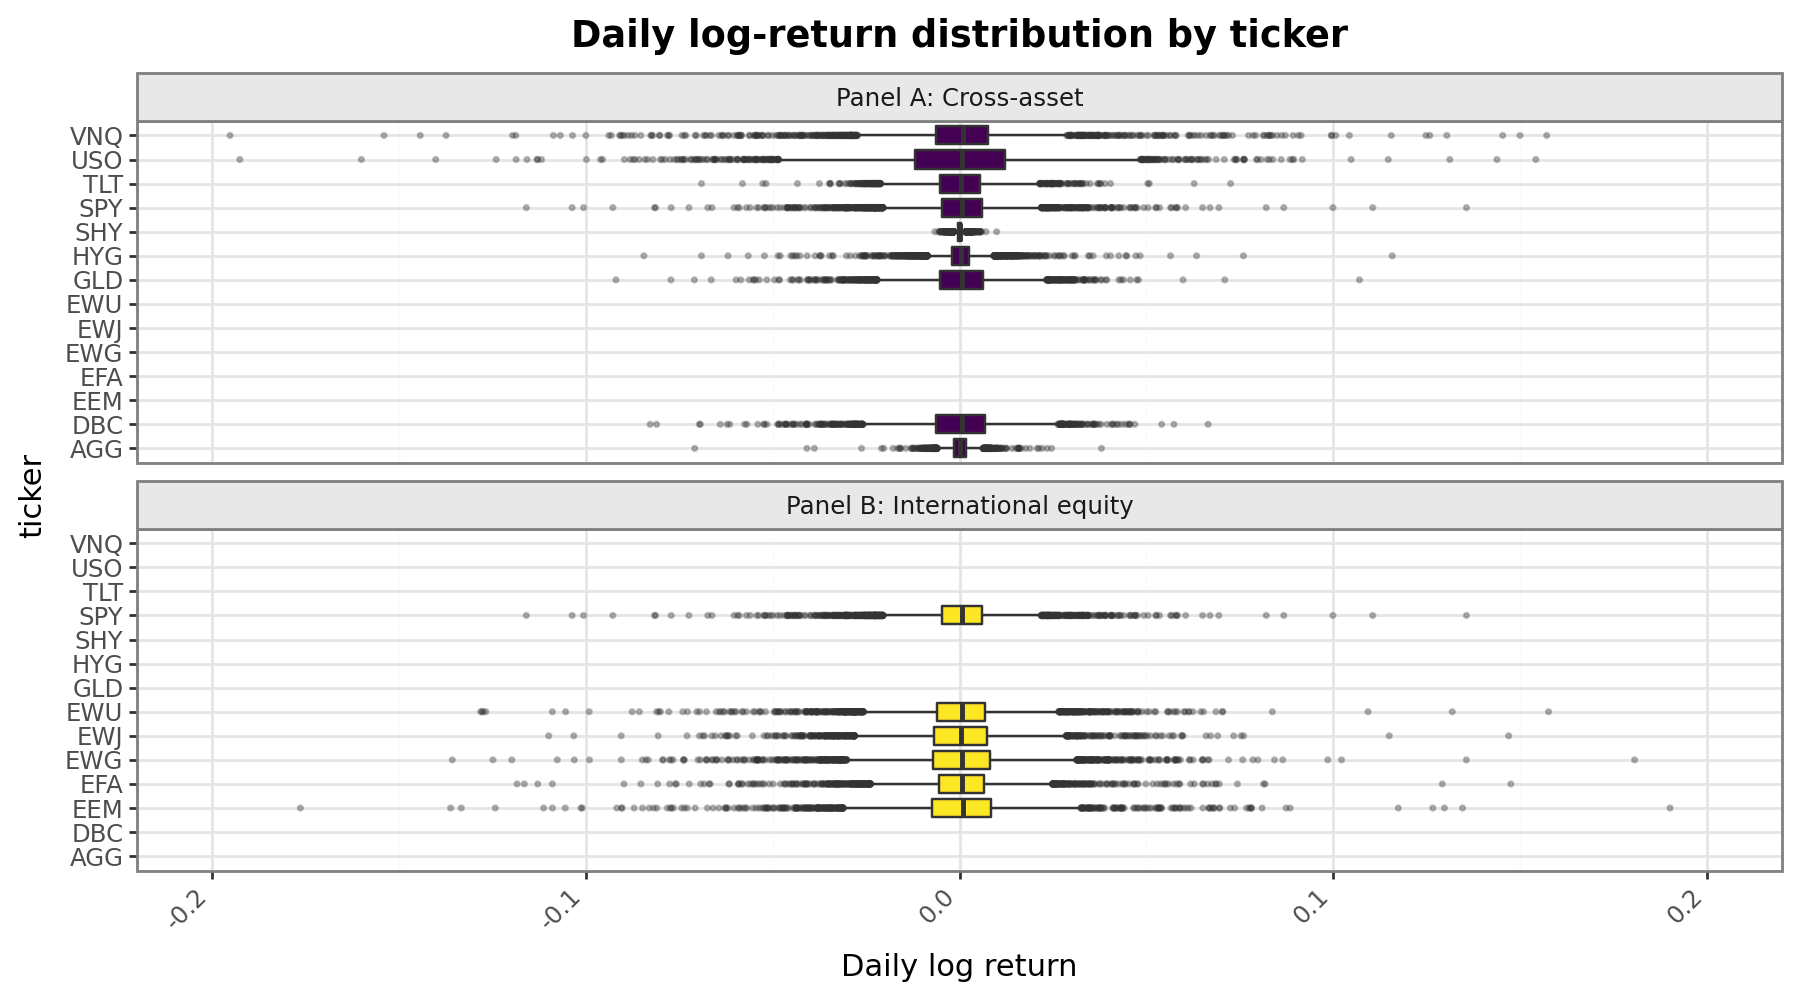

In [11]:
# --- Boxplots of returns, by panel ---
p_box = (
    ggplot(ret, aes(x="ticker", y="log_return", fill="panel"))
    + geom_boxplot(outlier_alpha=0.3, outlier_size=0.5)
    + facet_wrap("~panel", scales="fixed", ncol=1)
    + labs(title="Daily log-return distribution by ticker", x=None, y="Daily log return")
    + theme_seminar
    + theme(axis_text_x=element_text(rotation=45, hjust=1), legend_position="none")
    + coord_flip()
    + ylim(-0.2, 0.2)
)
save_fig(p_box, "return_boxplots_by_panel.png", width=9, height=7)
p_box

## 4. Normality and tail-risk diagnostics

A central premise of this paper is that the dependence structure across these assets cannot be safely modelled as Gaussian, since extreme co-movement ("diversification breakdown") is precisely what we study downstream. We test that premise formally here: significance of skewness and excess kurtosis against their asymptotic standard errors under normality, the joint Jarque–Bera test, and QQ-plots against the normal distribution.

In [12]:
# --- Skewness and excess-kurtosis significance under the null of normality ---
# Asymptotic standard errors (Snedecor & Cochran, 1989): SE(skew) = sqrt(6/n),
# SE(excess kurtosis) = sqrt(24/n). |z| > 1.96 rejects the normal value at 5%.
n = ret_stats["n"]
se_skew = np.sqrt(6 / n)
se_kurt = np.sqrt(24 / n)

diag = ret_stats[["n", "skew", "kurt_excess"]].copy()
diag["z_skew"] = diag["skew"] / se_skew
diag["z_kurt"] = diag["kurt_excess"] / se_kurt
diag["skew_sig_5pct"] = diag["z_skew"].abs() > 1.96
diag["kurt_sig_5pct"] = diag["z_kurt"].abs() > 1.96
diag.round(3)

n   skew  kurt_excess  z_skew  \
panel                         ticker                                     
Panel A: Cross-asset          AGG     5599 -2.051       54.571 -62.657   
                              DBC     5006 -0.488        3.346 -14.081   
                              GLD     5311 -0.336        5.870 -10.006   
                              HYG     4711  0.312       38.934   8.734   
                              SHY     5893  0.285        7.104   8.919   
                              SPY     6537 -0.209       11.536  -6.908   
                              TLT     5893 -0.019        3.401  -0.602   
                              USO     4962 -1.102       13.933 -31.700   
                              VNQ     5347 -0.536       18.730 -16.016   
Panel B: International equity EEM     5715  0.021       16.152   0.639   
                              EFA     6121 -0.320       12.658 -10.237   
                              EWG     6537 -0.220        9.010  -7.255   
                              EWJ     6537 -0.056        7.320  -1.852   
                              EWU     6537 -0.505       12.697 -16.685   
                              SPY     6537 -0.209       11.536  -6.908   

                                       z_kurt  skew_sig_5pct  kurt_sig_5pct  
panel                         ticker                                         
Panel A: Cross-asset          AGG     833.517           True           True  
                              DBC      48.326           True           True  
                              GLD      87.326           True           True  
                              HYG     545.480           True           True  
                              SHY     111.324           True           True  
                              SPY     190.384           True           True  
                              TLT      53.290          False           True  
                              USO     200.336           True           True  
                              VNQ     279.574           True           True  
Panel B: International equity EEM     249.251          False           True  
                              EFA     202.155           True           True  
                              EWG     148.697           True           True  
                              EWJ     120.809          False           True  
                              EWU     209.542           True           True  
                              SPY     190.384           True           True

In [13]:
# --- Jarque-Bera joint test of normality ---
jb_results = []
for (panel, ticker), g in ret.groupby(["panel", "ticker"], observed=True):
    jb_stat, jb_p = stats.jarque_bera(g["log_return"])
    jb_results.append({"panel": panel, "ticker": ticker, "jb_stat": jb_stat, "jb_pvalue": jb_p})

jb_df = pd.DataFrame(jb_results).set_index(["panel", "ticker"]).sort_index()
jb_df["reject_normality_5pct"] = jb_df["jb_pvalue"] < 0.05

normality_summary = diag.join(jb_df[["jb_stat", "jb_pvalue", "reject_normality_5pct"]])

# Reproducible output: combined skew/kurtosis/Jarque-Bera diagnostics.
normality_summary.to_csv(OUTPUT_DIR / "normality_diagnostics.csv")

normality_summary.round(3)

n   skew  kurt_excess  z_skew  \
panel                         ticker                                     
Panel A: Cross-asset          AGG     5599 -2.051       54.571 -62.657   
                              DBC     5006 -0.488        3.346 -14.081   
                              GLD     5311 -0.336        5.870 -10.006   
                              HYG     4711  0.312       38.934   8.734   
                              SHY     5893  0.285        7.104   8.919   
                              SPY     6537 -0.209       11.536  -6.908   
                              TLT     5893 -0.019        3.401  -0.602   
                              USO     4962 -1.102       13.933 -31.700   
                              VNQ     5347 -0.536       18.730 -16.016   
Panel B: International equity EEM     5715  0.021       16.152   0.639   
                              EFA     6121 -0.320       12.658 -10.237   
                              EWG     6537 -0.220        9.010  -7.255   
                              EWJ     6537 -0.056        7.320  -1.852   
                              EWU     6537 -0.505       12.697 -16.685   
                              SPY     6537 -0.209       11.536  -6.908   

                                       z_kurt  skew_sig_5pct  kurt_sig_5pct  \
panel                         ticker                                          
Panel A: Cross-asset          AGG     833.517           True           True   
                              DBC      48.326           True           True   
                              GLD      87.326           True           True   
                              HYG     545.480           True           True   
                              SHY     111.324           True           True   
                              SPY     190.384           True           True   
                              TLT      53.290          False           True   
                              USO     200.336           True           True   
                              VNQ     279.574           True           True   
Panel B: International equity EEM     249.251          False           True   
                              EFA     202.155           True           True   
                              EWG     148.697           True           True   
                              EWJ     120.809          False           True   
                              EWU     209.542           True           True   
                              SPY     190.384           True           True   

                                         jb_stat  jb_pvalue  \
panel                         ticker                          
Panel A: Cross-asset          AGG     697407.553        0.0   
                              DBC       2527.200        0.0   
                              GLD       7708.482        0.0   
                              HYG     296973.404        0.0   
                              SHY      12448.157        0.0   
                              SPY      36232.903        0.0   
                              TLT       2833.706        0.0   
                              USO      41050.780        0.0   
                              VNQ      78262.680        0.0   
Panel B: International equity EEM      62010.057        0.0   
                              EFA      40898.298        0.0   
                              EWG      22125.310        0.0   
                              EWJ      14572.562        0.0   
                              EWU      44112.429        0.0   
                              SPY      36232.903        0.0   

                                      reject_normality_5pct  
panel                         ticker                         
Panel A: Cross-asset          AGG                      True  
                              DBC                      True  
                              GLD                      True  
                              HYG                      T

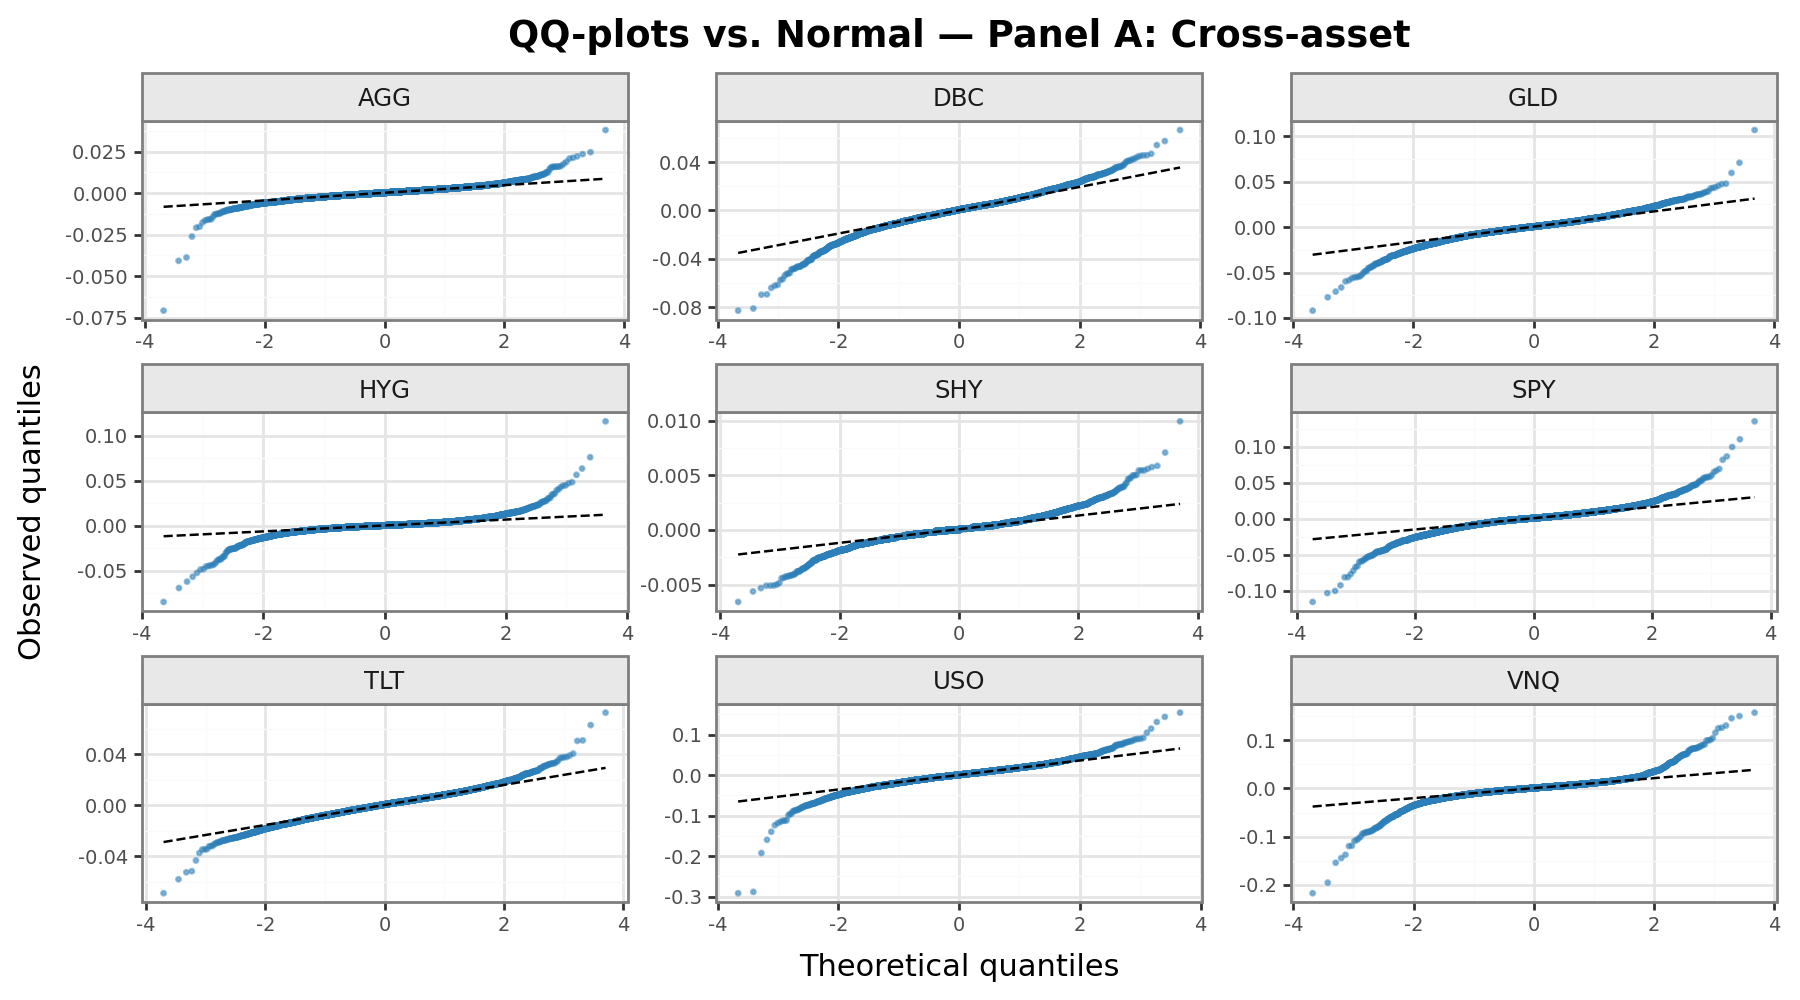

In [14]:
# --- QQ-plots against the normal distribution, Panel A (report figure) ---
ret_a = ret[ret["panel"] == "Panel A: Cross-asset"]
p_qq_a = (
    ggplot(ret_a, aes(sample="log_return"))
    + stat_qq(size=0.4, alpha=0.5, color="#2c7fb8")
    + stat_qq_line(color="black", linetype="dashed")
    + facet_wrap("~ticker", scales="free")
    + labs(title="QQ-plots vs. Normal — Panel A: Cross-asset", x="Theoretical quantiles", y="Observed quantiles")
    + theme_seminar
    + theme(axis_text=element_text(size=7))
)
save_fig(p_qq_a, "qq_plots_panel_a.png", width=10, height=8)
p_qq_a

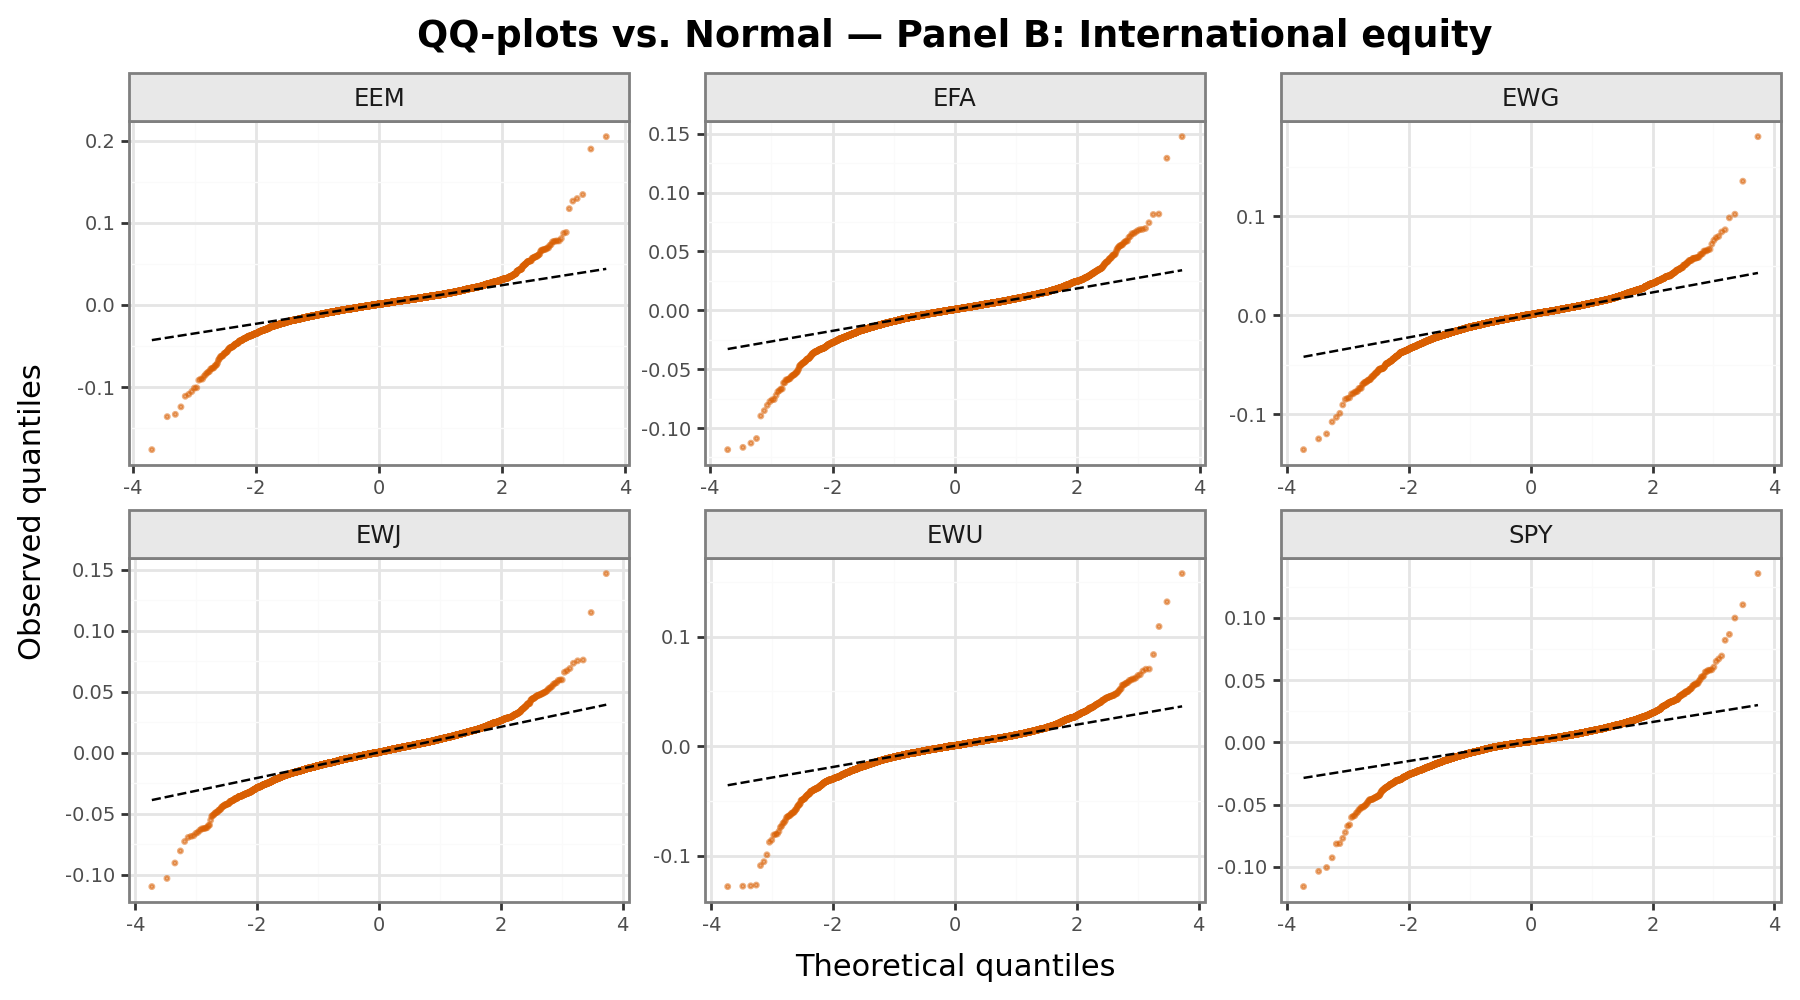

In [15]:
# --- QQ-plots against the normal distribution, Panel B (report figure) ---
ret_b = ret[ret["panel"] == "Panel B: International equity"]
p_qq_b = (
    ggplot(ret_b, aes(sample="log_return"))
    + stat_qq(size=0.4, alpha=0.5, color="#d95f02")
    + stat_qq_line(color="black", linetype="dashed")
    + facet_wrap("~ticker", scales="free")
    + labs(title="QQ-plots vs. Normal — Panel B: International equity", x="Theoretical quantiles", y="Observed quantiles")
    + theme_seminar
    + theme(axis_text=element_text(size=7))
)
save_fig(p_qq_b, "qq_plots_panel_b.png", width=10, height=6)
p_qq_b

## 5. Volatility clustering

Beyond unconditional fat tails, volatility itself is time-varying and persistent ("volatility clustering"): large moves tend to be followed by large moves. We visualise this with rolling 30-day annualised volatility, by panel.

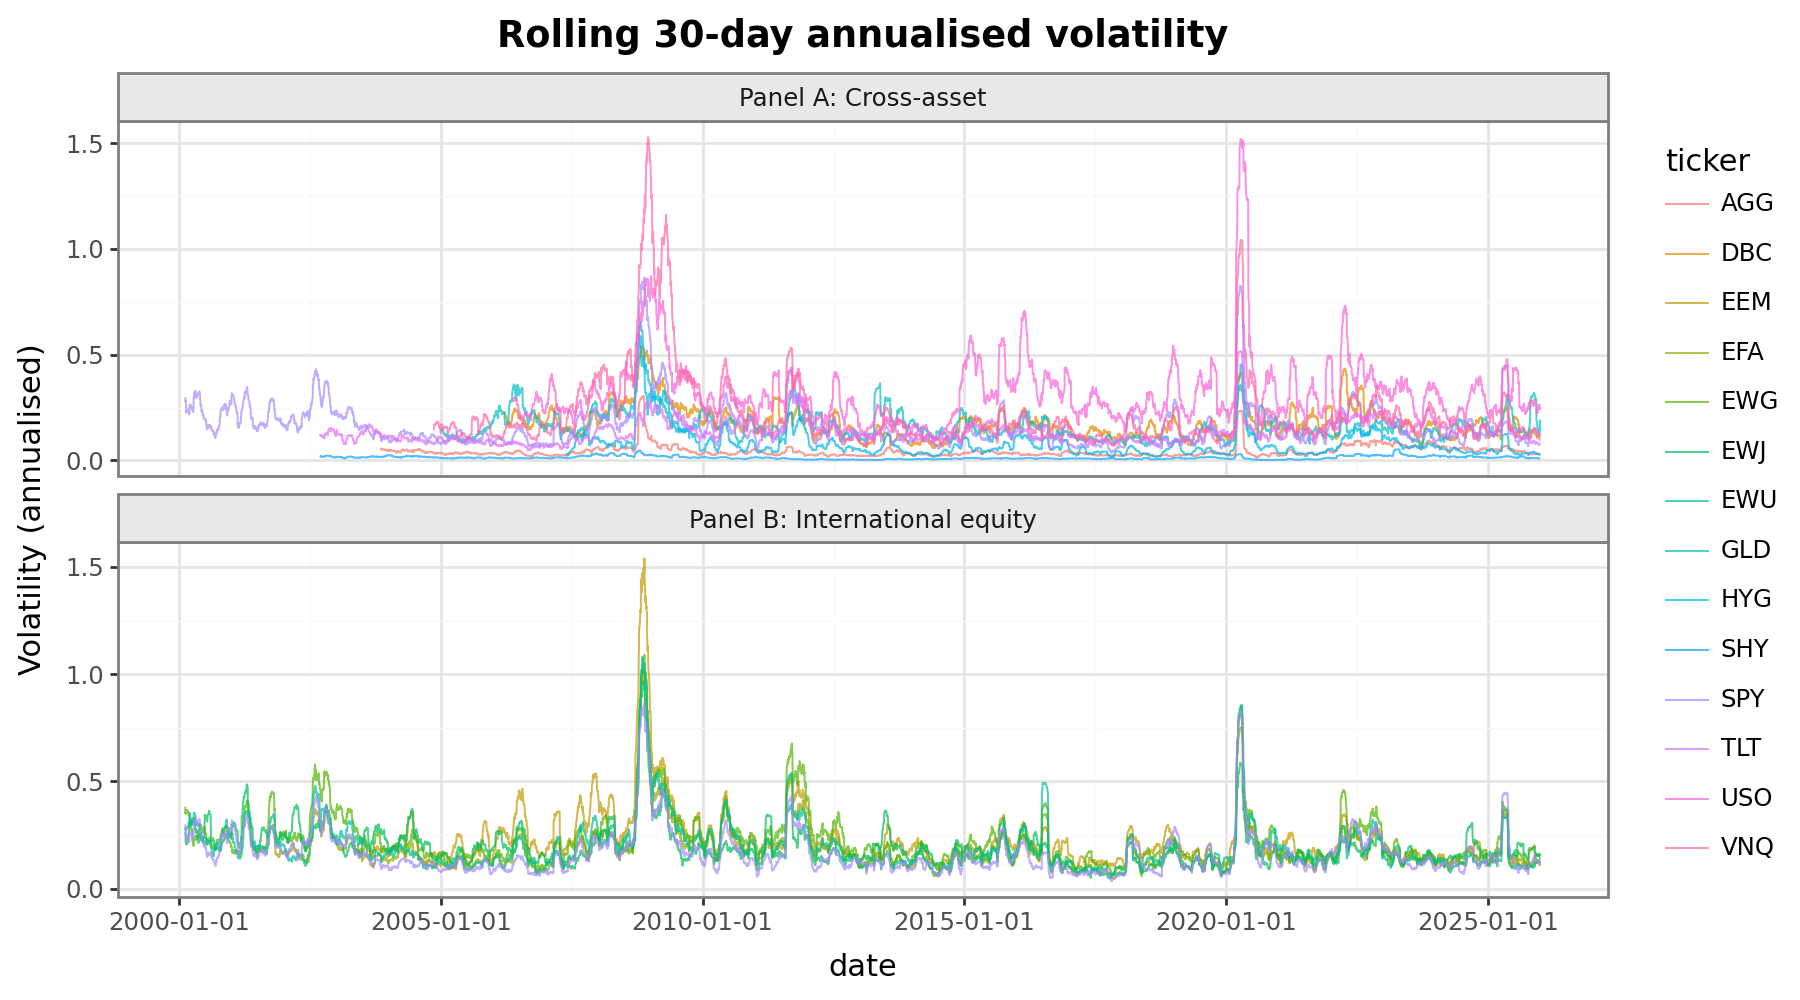

In [16]:
# --- Rolling 30-day annualised volatility, by panel ---
df["vol_30d"] = df.groupby(["panel", "ticker"], observed=True)["log_return"].transform(
    lambda x: x.rolling(30).std() * (252 ** 0.5)
)

p_vol = (
    ggplot(df.dropna(subset=["vol_30d"]), aes(x="date", y="vol_30d", color="ticker"))
    + geom_line(size=0.4, alpha=0.7)
    + facet_wrap("~panel", ncol=1, scales="free_y")
    + labs(title="Rolling 30-day annualised volatility", x=None, y="Volatility (annualised)")
    + theme_seminar
)
save_fig(p_vol, "rolling_volatility_30d.png", width=9, height=7)
p_vol

In [17]:
# --- Close the database connection and list the reproducible outputs ---
con.close()

written = [
    "asset_availability.csv",
    "descriptive_stats_panel_a.csv",
    "descriptive_stats_panel_b.csv",
    "normality_diagnostics.csv",
    "appendix_availability_tabular.tex",
    "appendix_desc_panel_a_tabular.tex",
    "appendix_desc_panel_b_tabular.tex",
    "asset_coverage_timeline.png",
    "normalized_price_history.png",
    "return_density_by_ticker.png",
    "return_boxplots_by_panel.png",
    "qq_plots_panel_a.png",
    "qq_plots_panel_b.png",
    "rolling_volatility_30d.png",
]
print(f"Wrote {len(written)} files to {OUTPUT_DIR}:")
for name in written:
    status = "ok" if (OUTPUT_DIR / name).exists() else "MISSING"
    print(f"  [{status}] {name}")

Wrote 14 files to C:\Users\salio\OneDrive\Desktop\University\TUM\Data Science in Finance\DataScienceSeminar\outputs\01_descriptive_data:
  [ok] asset_availability.csv
  [ok] descriptive_stats_panel_a.csv
  [ok] descriptive_stats_panel_b.csv
  [ok] normality_diagnostics.csv
  [ok] appendix_availability_tabular.tex
  [ok] appendix_desc_panel_a_tabular.tex
  [ok] appendix_desc_panel_b_tabular.tex
  [ok] asset_coverage_timeline.png
  [ok] normalized_price_history.png
  [ok] return_density_by_ticker.png
  [ok] return_boxplots_by_panel.png
  [ok] qq_plots_panel_a.png
  [ok] qq_plots_panel_b.png
  [ok] rolling_volatility_30d.png
